# Book-BAY
A premium library for book discovery and recommendations.

## Features Used
- Feature Engineering  
- Data Cleaning  

## Engineered Features
- Popularity-Based Recommendation System  
- Collaborative Filtering  
- Search Feature  
- Next Word Prediction  

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arashnic/book-recommendation-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'book-recommendation-dataset' dataset.
Path to dataset files: /kaggle/input/book-recommendation-dataset


In [7]:
!pip install transformers

In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.metrics.pairwise import cosine_similarity


In [9]:
os.listdir('/kaggle/input/book-recommendation-dataset')

['Ratings.csv',
 'Users.csv',
 'classicRec.png',
 'Books.csv',
 'DeepRec.png',
 'recsys_taxonomy2.png']

In [10]:
ratings = pd.read_csv('/kaggle/input/book-recommendation-dataset/Ratings.csv')
users = pd.read_csv('/kaggle/input/book-recommendation-dataset/Users.csv')
books = pd.read_csv('/kaggle/input/book-recommendation-dataset/Books.csv')

/tmp/ipykernel_4818/336120385.py:3: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv('/kaggle/input/book-recommendation-dataset/Books.csv')


In [11]:
# Print Image

In [12]:
# from IPython.display import Image

# # Assuming the image is in the dataset path identified earlier
# image_path = '/kaggle/input/book-recommendation-dataset/classicRec.png'
# Image(filename=image_path)

In [13]:
# from IPython.display import Image

# # Assuming the image is in the dataset path identified earlier
# image_path = '/kaggle/input/book-recommendation-dataset/recsys_taxonomy2.png'
# Image(filename=image_path)

In [14]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [15]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [16]:
users.columns, books.columns, ratings.columns

(Index(['User-ID', 'Location', 'Age'], dtype='object'),
 Index(['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher',
        'Image-URL-S', 'Image-URL-M', 'Image-URL-L'],
       dtype='object'),
 Index(['User-ID', 'ISBN', 'Book-Rating'], dtype='object'))

In [17]:
#total of users that gave multiple no of ratings
users_multiple_ratings = ratings.groupby("User-ID").size()
total_users = (users_multiple_ratings > 1).sum()

In [18]:
ratings_per_user = ratings.groupby("User-ID").size()

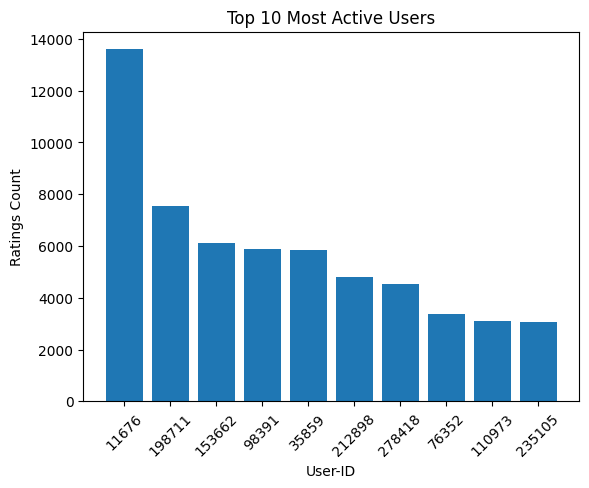

In [19]:
top_users = ratings_per_user.sort_values(ascending=False).head(10)

plt.figure()
plt.bar(top_users.index.astype(str), top_users.values)
plt.xlabel("User-ID")
plt.ylabel("Ratings Count")
plt.title("Top 10 Most Active Users")
plt.xticks(rotation=45)
plt.show()


# Popularity Based System

In [20]:
ratings_with_name = ratings.merge(books, on="ISBN")
num_ratings_df = ratings_with_name.groupby('Book-Title').count()['Book-Rating'].reset_index()
num_ratings_df.rename(columns={'Book-Rating':'num_ratings'},inplace=True)
num_ratings_df

,Book-Title,num_ratings
0,A Light in the Storm: The Civil War Diary of ...,4
1,Always Have Popsicles,1
2,Apple Magic (The Collector's series),1
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1
4,Beyond IBM: Leadership Marketing and Finance ...,1
...,...,...
241066,Ã?Â?lpiraten.,2
241067,Ã?Â?rger mit Produkt X. Roman.,4
241068,Ã?Â?sterlich leben.,1
241069,Ã?Â?stlich der Berge.,3


In [21]:
avg_ratings_df = (ratings_with_name.groupby('Book-Title')['Book-Rating'].mean().reset_index())

In [22]:
avg_ratings_df.rename(columns={'Book-Rating':'avg_rating'},inplace=True)
avg_ratings_df

,Book-Title,avg_rating
0,A Light in the Storm: The Civil War Diary of ...,2.250000
1,Always Have Popsicles,0.000000
2,Apple Magic (The Collector's series),0.000000
3,"Ask Lily (Young Women of Faith: Lily Series, ...",8.000000
4,Beyond IBM: Leadership Marketing and Finance ...,0.000000
...,...,...
241066,Ã?Â?lpiraten.,0.000000
241067,Ã?Â?rger mit Produkt X. Roman.,5.250000
241068,Ã?Â?sterlich leben.,7.000000
241069,Ã?Â?stlich der Berge.,2.666667


In [23]:
popularity_df = num_ratings_df.merge(avg_ratings_df,on='Book-Title')
popularity_df

,Book-Title,num_ratings,avg_rating
0,A Light in the Storm: The Civil War Diary of ...,4,2.250000
1,Always Have Popsicles,1,0.000000
2,Apple Magic (The Collector's series),1,0.000000
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1,8.000000
4,Beyond IBM: Leadership Marketing and Finance ...,1,0.000000
...,...,...,...
241066,Ã?Â?lpiraten.,2,0.000000
241067,Ã?Â?rger mit Produkt X. Roman.,4,5.250000
241068,Ã?Â?sterlich leben.,1,7.000000
241069,Ã?Â?stlich der Berge.,3,2.666667


In [24]:
popular_df = popularity_df[popularity_df['num_ratings'] >= 250].sort_values('avg_rating',ascending=False).head(50)
popular_df = popular_df.merge(books,on='Book-Title').drop_duplicates('Book-Title')[['Book-Title','Book-Author','Image-URL-M','num_ratings','avg_rating']]

# Collaborative Filtering

In [25]:
x = ratings_with_name.groupby("User-ID").count()['Book-Rating'] > 0
padhe_likhe_users = x[x].index

In [26]:
filtered_rating = ratings_with_name[ratings_with_name['User-ID'].isin(padhe_likhe_users)]

In [27]:
y = filtered_rating.groupby("Book-Title").count()['Book-Rating'] >= 50

In [28]:
famous_books = y[y].index

In [29]:
famous_books

Index(['10 Lb. Penalty', '16 Lighthouse Road', '1984', '1st to Die: A Novel',
       '2010: Odyssey Two', '204 Rosewood Lane', '2061: Odyssey Three',
       '24 Hours', '2nd Chance', '3rd Degree',
       ...
       'YOU BELONG TO ME', 'Year of Wonders', 'You Belong To Me',
       'You Shall Know Our Velocity', 'Young Wives',
       'Zen and the Art of Motorcycle Maintenance: An Inquiry into Values',
       'Zoya', '\O\" Is for Outlaw"',
       '\Surely You're Joking, Mr. Feynman!\": Adventures of a Curious Character"',
       'stardust'],
      dtype='object', name='Book-Title', length=2444)

In [30]:
# famous_books

In [31]:
final_ratings = filtered_rating[filtered_rating['Book-Title'].isin(famous_books)]

In [32]:
pt = final_ratings.pivot_table(index='Book-Title',columns='User-ID',values='Book-Rating')

In [33]:
pt.fillna(0, inplace = True)

In [34]:
similarity_score = cosine_similarity(pt)

In [35]:
from re import template
def recommend(book_name):
  # book name
  index = np.where(pt.index == book_name)[0][0]
  similar_items = sorted(list(enumerate(similarity_score[index])), key=lambda x:x[1], reverse=True)[1:6]

  data = []
  for i in similar_items:
    item = []
    temp_df = books[books['Book-Title'] == pt.index[i[0]]]
    item.extend(list(temp_df.drop_duplicates('Book-Title')['Book-Title'].values))
    item.extend(list(temp_df.drop_duplicates('Book-Title')['Book-Author'].values))
    item.extend(list(temp_df.drop_duplicates('Book-Title')['Image-URL-M'].values))
    item.extend(list(temp_df.drop_duplicates('Book-Title')['Publisher'].values))
    data.append(item)
  return data


In [36]:
# recommend('The Return of the King (The Lord of the Rings, Part 3)')

# Search Feature : Using TF-IDF

In [37]:
df = books

In [38]:
df

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...
...,...,...,...,...,...,...,...,...
271355,0440400988,There's a Bat in Bunk Five,Paula Danziger,1988,Random House Childrens Pub (Mm),http://images.amazon.com/images/P/0440400988.0...,http://images.amazon.com/images/P/0440400988.0...,http://images.amazon.com/images/P/0440400988.0...
271356,0525447644,From One to One Hundred,Teri Sloat,1991,Dutton Books,http://images.amazon.com/images/P/0525447644.0...,http://images.amazon.com/images/P/0525447644.0...,http://images.amazon.com/images/P/0525447644.0...
271357,006008667X,Lily Dale : The True Story of the Town that Ta...,Christine Wicker,2004,HarperSanFrancisco,http://images.amazon.com/images/P/006008667X.0...,http://images.amazon.com/images/P/006008667X.0...,http://images.amazon.com/images/P/006008667X.0...
271358,0192126040,Republic (World's Classics),Plato,1996,Oxford University Press,http://images.amazon.com/images/P/0192126040.0...,http://images.amazon.com/images/P/0192126040.0...,http://images.amazon.com/images/P/0192126040.0...


In [39]:
df["combined"] = (
    (df["Book-Title"] + " ") * 3 +
    (df["Book-Author"] + " ") * 2 +
    df["Publisher"]
).str.lower()
df.fillna("", inplace=True)
df.shape

(271360, 9)

In [40]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    max_df=0.85,
    min_df=2,
    sublinear_tf=True,
    strip_accents='unicode'
)

tfidf_matrix = vectorizer.fit_transform(df["combined"])

def search_similar(text, top_n=5):
    query_vec = vectorizer.transform([text])
    similarity = cosine_similarity(query_vec, tfidf_matrix).flatten()

    top_indices = similarity.argsort()[-top_n:][::-1]

    return df.iloc[top_indices]["Book-Title"]

In [41]:
print(f"{search_similar("mockingbird")}")



186164              Mockingbird
217505              Mockingbird
246955              Mockingbird
114038    To Kill a Mockingbird
57705     To Kill a Mockingbird
Name: Book-Title, dtype: object


# Next Word Prediction

In [42]:
popularity_df.shape

(241071, 3)

In [43]:
popular_df = popularity_df[popularity_df['num_ratings'] > 100]

In [44]:
popular_df.shape

(904, 3)

In [45]:
corpus = " ".join(popular_df['Book-Title'].astype(str))

In [46]:
corpus

'1984 1st to Die: A Novel 24 Hours 2nd Chance 4 Blondes 84 Charing Cross Road A Beautiful Mind: The Life of Mathematical Genius and Nobel Laureate John Nash A Bend in the Road A Case of Need A Child Called \\It\\": One Child\'s Courage to Survive" A Civil Action A Confederacy of Dunces (Evergreen Book) A Dangerous Fortune A Darkness More Than Night A Day Late and a Dollar Short A Fine Balance A Girl Named Zippy: Growing Up Small in Mooreland Indiana (Today Show Book Club #3) A Heartbreaking Work of Staggering Genius A Is for Alibi (Kinsey Millhone Mysteries (Paperback)) A Lesson Before Dying (Vintage Contemporaries (Paperback)) A Light in the Window (The Mitford Years) A Man Named Dave: A Story of Triumph and Forgiveness A Man in Full A Map of the World A Painted House A Patchwork Planet A Prayer for Owen Meany A Separate Peace A Thin Dark Line (Mysteries &amp; Horror) A Thousand Acres (Ballantine Reader\'s Circle) A Time to Kill A Tree Grows in Brooklyn A Virtuous Woman (Oprah\'s Book

In [47]:
tokenizer = Tokenizer()

In [48]:
tokenizer.fit_on_texts([corpus])

In [49]:
len(tokenizer.word_index)

1511

In [50]:
input_sequences = []
for sentence in popular_df['Book-Title']:
  token_list = tokenizer.texts_to_sequences([sentence])[0]

  for i in range(1, len(token_list)):
    input_sequences.append(token_list[:i+1])

In [51]:
input_sequences

[[512, 9],
 [512, 9, 513],
 [512, 9, 513, 3],
 [512, 9, 513, 3, 4],
 [514, 172],
 [515, 267],
 [122, 268],
 [516, 517],
 [516, 517, 54],
 [516, 517, 54, 70],
 [3, 269],
 [3, 269, 123],
 [3, 269, 123, 1],
 [3, 269, 123, 1, 36],
 [3, 269, 123, 1, 36, 2],
 [3, 269, 123, 1, 36, 2, 518],
 [3, 269, 123, 1, 36, 2, 518, 173],
 [3, 269, 123, 1, 36, 2, 518, 173, 5],
 [3, 269, 123, 1, 36, 2, 518, 173, 5, 519],
 [3, 269, 123, 1, 36, 2, 518, 173, 5, 519, 520],
 [3, 269, 123, 1, 36, 2, 518, 173, 5, 519, 520, 521],
 [3, 269, 123, 1, 36, 2, 518, 173, 5, 519, 520, 521, 522],
 [3, 270],
 [3, 270, 10],
 [3, 270, 10, 1],
 [3, 270, 10, 1, 70],
 [3, 124],
 [3, 124, 2],
 [3, 124, 2, 271],
 [3, 272],
 [3, 272, 523],
 [3, 272, 523, 55],
 [3, 272, 523, 55, 20],
 [3, 272, 523, 55, 20, 273],
 [3, 272, 523, 55, 20, 273, 524],
 [3, 272, 523, 55, 20, 273, 524, 9],
 [3, 272, 523, 55, 20, 273, 524, 9, 525],
 [3, 526],
 [3, 526, 274],
 [3, 527],
 [3, 527, 2],
 [3, 527, 2, 528],
 [3, 527, 2, 528, 529],
 [3, 527, 2, 528,

In [52]:
max_len =  max([len(x) for x in input_sequences])

In [53]:
max_len

28

In [54]:

padded_input_sequences = pad_sequences(input_sequences, maxlen = max_len, padding='pre')

In [55]:
padded_input_sequences

array([[   0,    0,    0, ...,    0,  512,    9],
       [   0,    0,    0, ...,  512,    9,  513],
       [   0,    0,    0, ...,    9,  513,    3],
       ...,
       [   0,    0,    0, ...,    0, 1510,   12],
       [   0,    0,    0, ..., 1510,   12,    8],
       [   0,    0,    0, ...,   12,    8, 1511]], dtype=int32)

In [56]:
x = padded_input_sequences[:,:-1]
y = padded_input_sequences[:,-1]

In [57]:
vocab_size = len(tokenizer.word_index) + 1

In [58]:
vocab_size

1512

In [59]:
y = to_categorical(y, num_classes=vocab_size)

In [60]:
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=100, input_length=27))
model.add(LSTM(150, return_sequences=True))
model.add(LSTM(150))
model.add(Dense(vocab_size, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [61]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [62]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [66]:
model.fit(x,y,epochs=100)


Epoch 1/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.0569 - loss: 6.7217
Epoch 2/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0550 - loss: 6.1957
Epoch 3/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0550 - loss: 6.0116
Epoch 4/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0921 - loss: 5.8090
Epoch 5/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0970 - loss: 5.6311
Epoch 6/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1019 - loss: 5.4711
Epoch 7/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.1175 - loss: 5.3076
Epoch 8/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.1363 - loss: 5.1572
Epoch 9/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1568 - loss: 4.9984
Epoch 10/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1744 - loss: 4.8397
Epoch 11/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1868 - loss: 4.6868
Epoch 12/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accur

In [64]:
import time
text = "Harry"

for i in range(10):
  token_list = tokenizer.texts_to_sequences([text])[0]
  token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
  predicted = model.predict(token_list)
  predicted_index = np.argmax(predicted)
  output_word = ""
  for word, index in tokenizer.word_index.items():
    if index == predicted_index:
      output_word = word
      break
  text += " " + output_word
print(text)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Harry nobody nobody nobody nobody nobody instance instance with with ireland


In [ ]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)